In [8]:
import sys
from pathlib import Path

# Add parent directory (where utility.py lives) to the path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
import math

from utility import GroupwisePLSTransformer, _feature_engineering, setpoint_df, ewm_reset

from config import CONTROL_VARS
from data_cleaning import (
    unique_in_order, ordered_difference, ordered_intersection,
    outlier, make_design,
)
from preprocessing import make_prep_pip

sns.set(rc={"figure.figsize": (12, 4)})
sns.set_style("whitegrid")
sns.set_context("notebook")

In [4]:
Y_COLUMN = "Steam_power"
DATA_PATH = "../data/costimier_turnup.parquet"

TIME_AWARE = True
USE_HOLDOUT = True
APPLY_EWM_FILTER = True
DEMEAN_BY_GRAMMAGE = False

TEST_SIZE = 0.20
RANDOM_STATE = 42
N_SPLITS = 5
LAGS = 0


PIPELINE_PREFIXES = {
    "Steam_power":["steam_pressure", "exha_mois", "inlet_temp", "vacuum", "linepressure","fabric_tension","gas_decu"],
    "Electrical_power_MW": ["speedsizer_linepressure", "linepressure"],
    "Starch_uptake_by_paper_Top_Roll__g/m2_": ["speedsizer_linepressure", "linepressure","starch2"],
    "Starch_uptake_by_paper_Bottom_Roll__g/m2_": ["speedsizer_linepressure", "linepressure","starch1"],
    "MBS_SCT_CD": ["draw", "speedsizer_linepressure", "linepressure", "conc_starch"],
    "MBS_SCT_MD": ["draw", "speedsizer_linepressure", "linepressure", "conc_starch"],
    "MBS_Burst": ["draw", "speedsizer_linepressure", "linepressure", "conc_starch"],
    "MBS_CMT30": ["draw", "speedsizer_linepressure", "linepressure", "conc_starch"],

}

BLACK_LIST = {
    "Steam_power": [
        "Current_basis_weight", 
        "Bentonite_1_mass_flow__g/T_",
        "Bentonite_2_mass_flow__g/T_", 
        "DG3_Moisture_content_Outlet_Air",
        "Lip_settings", 
        "Conductivity_white_water_B46",
        "pH-Messung_Verd\u00fcnnungswasser__2..12_pH_",
        "pH_measurement_white_water_B41", 
        "CO2_mass_flow__g/T_",
    ],
    "Electrical_power_MW": [
        "Current_basis_weight", 
        "Bentonite_1_mass_flow__g/T_",
        "Bentonite_2_mass_flow__g/T_", 
        "DG3_Moisture_content_Outlet_Air",
        "Lip_settings", 
        "Conductivity_white_water_B46",
        "pH-Messung_Verd\u00fcnnungswasser__2..12_pH_",
        "pH_measurement_white_water_B41", 
        "CO2_mass_flow__g/T_",
    ],
    "Starch_uptake_by_paper_Top_Roll__g/m2_": [
        "Bentonite_1_mass_flow__g/T_",
        "Bentonite_2_mass_flow__g/T_", 
        "DG3_Moisture_content_Outlet_Air",
        "Lip_settings", 
        "Conductivity_white_water_B46",
        "pH-Messung_Verd\u00fcnnungswasser__2..12_pH_",
        "pH_measurement_white_water_B41", "CO2_mass_flow__g/T_",
    ],
    "Starch_uptake_by_paper_Bottom_Roll__g/m2_": [
        "Bentonite_1_mass_flow__g/T_",
        "Bentonite_2_mass_flow__g/T_", 
        "DG3_Moisture_content_Outlet_Air",
        "Lip_settings", 
        "Conductivity_white_water_B46",
        "pH-Messung_Verd\u00fcnnungswasser__2..12_pH_",
        "pH_measurement_white_water_B41", "CO2_mass_flow__g/T_",
    ],
    "MBS_SCT_CD": [
        'Bentonite_1_mass_flow__g/T_',
        'Bentonite_2_mass_flow__g/T_',
        'DG3_Moisture_content_Outlet_Air',               
        'Conductivity_white_water_B46',
        'pH-Messung_Verdünnungswasser__2..12_pH_', 
        'pH_measurement_white_water_B41',
        'CO2_mass_flow__g/T_',
        "Current_reel_moisture_average(reel)"
     ],
    "MBS_SCT_MD": [
        'Bentonite_1_mass_flow__g/T_',
        'Bentonite_2_mass_flow__g/T_',
        'DG3_Moisture_content_Outlet_Air',               
        'Conductivity_white_water_B46',
        'pH-Messung_Verdünnungswasser__2..12_pH_', 
        'pH_measurement_white_water_B41',
        'CO2_mass_flow__g/T_',
        "Current_reel_moisture_average(reel)"
     ],
     "MBS_Burst": [
        'Bentonite_1_mass_flow__g/T_',
        'Bentonite_2_mass_flow__g/T_',
        'DG3_Moisture_content_Outlet_Air',               
        'Conductivity_white_water_B46',
        'pH-Messung_Verdünnungswasser__2..12_pH_', 
        'pH_measurement_white_water_B41',
        'CO2_mass_flow__g/T_',
        "Current_reel_moisture_average(reel)"
     ],
     "MBS_CMT30": [
        'Bentonite_1_mass_flow__g/T_',
        'Bentonite_2_mass_flow__g/T_',
        'DG3_Moisture_content_Outlet_Air',               
        'Conductivity_white_water_B46',
        'pH-Messung_Verdünnungswasser__2..12_pH_', 
        'pH_measurement_white_water_B41',
        'CO2_mass_flow__g/T_',
        "Current_reel_moisture_average(reel)"
     ],
}

CREATED_VARIABLE_CANDIDATES = {
    "Steam_power": [
        "Water_flow_Predryer",                                    
        "Fibre__g/m2_",
        "Water_flow_Afterdryer_input", 
        "Water_flow_Afterdryer_output",
        "dewatering",
        "fibre_short/long",
        "Production_Rate__T/h_"
    ],
    "Electrical_power_MW": [
        "dewatering",
        "Fibre__g/m2_",
    ],
     "Starch_uptake_by_paper_Top_Roll__g/m2_": [
        "delta_basis_weight",
        "Water_flow_Predryer",            
        "Water_flow",                               
        "inv_Rod_pressure_Top_Roll",
        "square_Rod_pressure_Top_Roll",
     ],
     "Starch_uptake_by_paper_Bottom_Roll__g/m2_":[
        "delta_basis_weight",
        "Water_flow_Predryer",            
        "Water_flow",                               
        "inv_Rod_Pressure_Bottom_Roll",
        "square_Rod_Pressure_Bottom_Roll",
     ],
     "MBS_SCT_CD": [
        "delta_basis_weight",
        "Starch_uptake__g/m2_",
        "Water_flow_Predryer",
        "Water_flow_Afterdryer",
        "Water_flow",
        "flow_diluted_starch",
        "Fibre__g/m2_",
        "Water_flow_Afterdryer_input", 
        "Water_flow_Afterdryer_output",
        "dewatering",
        "fibre_short/long",
        "temperature_starch_working_tank"

     ],
}

<Axes: xlabel='Steam_consumption', ylabel='Steam__kWh/T_'>

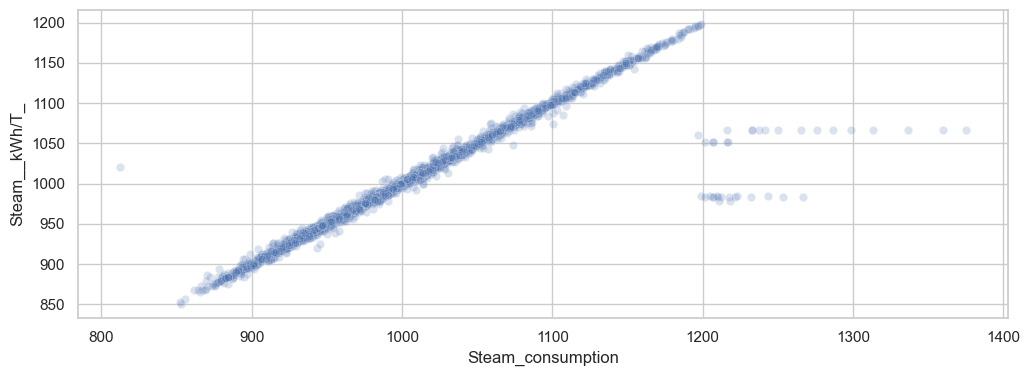

In [13]:
sns.scatterplot(turnup_data, x="Steam_consumption", y="Steam__kWh/T_", alpha=0.2)

In [12]:
# Build PLS preprocessing pipeline
prep_pip, prep_s_vars = make_prep_pip(prefixes=PIPELINE_PREFIXES[Y_COLUMN])

# Load raw data
turnup_data = pd.read_parquet(DATA_PATH)

cond_col = turnup_data['Condensate_energy_from_paper_plant_to_power_plant']
cond_med = cond_col[(cond_col >= 0) & (cond_col <= 10)].median()
if  math.isnan(cond_med) :
    cond_med = 5.11
cond = cond_col.where((cond_col >= 0) & (cond_col <= 10), cond_med)

turnup_data["Steam_power"] = turnup_data['Steam_flow_to_PM'] + turnup_data['Waste_steam_flow'] 
turnup_data["Steam_consumption"]  = (((turnup_data["Steam_power"] * 0.788 - cond) * 1.02 - (0.5938 / 24)) / turnup_data["Production_Rate__T/h_"]) * 1000
turnup_data["Electrical_power_MW"] = (
    turnup_data['Summe_Energieverbrauch_APA_in_kW'] + 
    turnup_data['Mehrmotorenantrieb_Former__-1..10_MW_']*1000 +
    turnup_data['Mehrmotorenantrieb_Presse__-1..10_MW_']*1000 +
    turnup_data['VariSTEP_div._Hauben+Lueftung_Ventilatoren']*1000 +
    turnup_data['VariSTEP_div._Hauben+Lueftung_Ventilatoren']*1000 +
    turnup_data['Varisprint_660V__-10..10_MW_']*1000 +
    turnup_data['Varisprint_400V__-10..10_MW_']*1000 +
    turnup_data['Mehrmotorenantrieb_Trockenpartie__-1..10_MW_']*1000 +
    turnup_data['PM_400V__-1..10_MW_']*1000 +
    turnup_data['PM_660V_Festantriebe_Verteiler2__-1..10_MW_']*1000 +
    turnup_data['PM_660V_Festantriebe_Verteiler3__-1..10_MW_']*1000 +
    turnup_data['PM_660V_Festantriebe_Verteiler3__-1..10_MW_~^0']*1000 +
    turnup_data['PM_660V_Festantriebe_Verteiler2__-1..10_MW_~^1']*1000 +
    turnup_data['PM_660V_Festantriebe_Verteiler1__-1..10_MW_~^0']*1000 +
    turnup_data['PM_660V_Festantriebe_Verteiler1__-1..10_MW_~^1']*1000 +
    turnup_data['MCC_Einzel-FU_660V__-10..10_MW_~^0']*1000 +
    turnup_data['MCC_Einzel-FU_660V__-10..10_MW_~^1']*1000 +
    turnup_data['Last_Antrieb_10_1.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_11_1.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_12_2.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_13_2.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_14_2.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_15_3.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_16_3.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_17_3.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_18_4.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_19_4.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_20_4.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_21_4.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_22_5.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_23_5.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_24_5.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_25_5.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_31_6.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_32_6.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_33_6.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_34_6.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_35_6.TG__0..100_kW_'] +
    turnup_data['Last_Antrieb_36_7.TG__0..200_kW_'] +
    turnup_data['Last_Antrieb_37_7.TG__0..200_kW_'] +
    turnup_data['Last_Antrieb_38_7.TG__0..200_kW_'] +
    turnup_data['Last_Antrieb_39_7.TG__0..200_kW_'] 
    
)/1000

# Get control variables for the target (excluding vacuum)
ctl_vars = unique_in_order(
    v for v in CONTROL_VARS[Y_COLUMN]  if "vacuum" not in v.lower()
)

# Derived variables are created inside build_pre_estimator via FeatureCreator
created_vars = ordered_intersection(CREATED_VARIABLE_CANDIDATES[Y_COLUMN], ctl_vars)

# Feature engineering
turnup_data = _feature_engineering(turnup_data, setpoint_df, steam_null=False, clip=False)
turnup_data = turnup_data.set_index("Wedge_Time").sort_index()

# Time-based filtering
if Y_COLUMN == 'Steam_power':
    turnup_data = turnup_data[turnup_data.index > "2026-1-1"]
    turnup_data = turnup_data[~((turnup_data.index > "2026-01-24 07:00") & (turnup_data.index < "2026-01-26 10:00"))]
    turnup_data = turnup_data[~((turnup_data.index > "2026-01-11 12:00") & (turnup_data.index < "2026-01-12 11:00"))]
    turnup_data = turnup_data[~((turnup_data.index > "2026-01-17 12:00") & (turnup_data.index < "2026-01-19 11:00"))]
    turnup_data = turnup_data[turnup_data.index < "2026-07-1"]

    # Physical-constraint filtering
    turnup_data = turnup_data[
        #(turnup_data["Condensate_energy_from_paper_plant_to_power_plant"].between(5, 10))
        #& 
        (turnup_data["DG4_Temperature_Inlet_Air"] > 100)
        & 
        (turnup_data["Vacuum_Zone_1_PickUp"] < -0.5)
    ]
if Y_COLUMN == 'Electrical_power_MW':    
    turnup_data = turnup_data[turnup_data.index > "2025-11-15"]
    turnup_data = turnup_data[~((turnup_data.index > "2026-01-24 07:00") & (turnup_data.index < "2026-01-26 10:00"))]
    turnup_data = turnup_data[turnup_data.index < "2026-07-1"]

#turnup_data = turnup_data[turnup_data[]]

print(f"Filtered data shape: {turnup_data.shape}")

Filtered data shape: (3216, 525)


In [9]:
turnup_ts["concentration_starch_working_tank_2"]

Wedge_Time
2026-01-02 17:23:30    12.478040
2026-01-02 18:49:30    12.453479
2026-01-02 19:46:30    12.460792
2026-01-02 20:43:30    12.530524
2026-01-02 21:39:30    13.054268
                         ...    
2026-06-30 20:06:30    12.494452
2026-06-30 21:10:30    12.507818
2026-06-30 22:06:30    12.507229
2026-06-30 23:02:30    13.491188
2026-06-30 23:59:30    13.510163
Name: concentration_starch_working_tank_2, Length: 3214, dtype: float32

<Axes: xlabel='Wedge_Time', ylabel='Electrical_power_MW'>

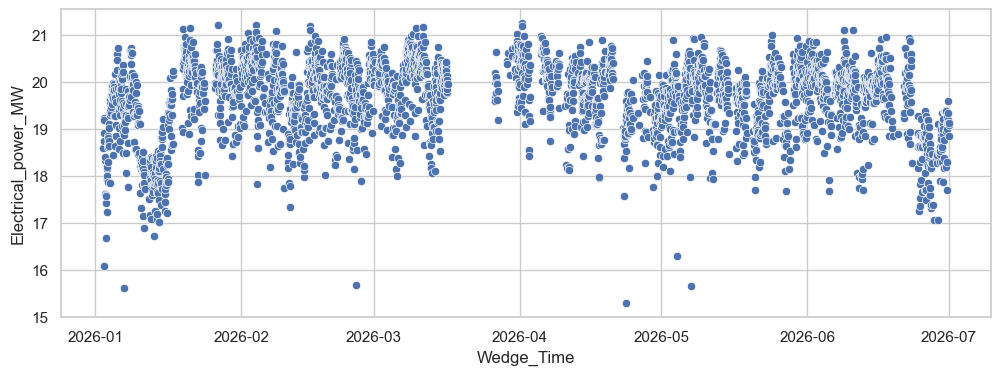

In [23]:
sns.scatterplot(turnup_data.reset_index(), x="Wedge_Time", y='Electrical_power_MW')

In [4]:
import re
from preprocessing import build_pre_estimator

# Determine fixed features (always included in CMA-ES)
fixed_features = [
    "grammage",
]

# Build reduced candidate variable list (desired output features)
steam_pressure = [v for v in turnup_data.columns if re.search(r"cylinder.*steam_pressure", v, re.I)]
steam_diff_pressure = [v for v in turnup_data.columns if re.search(r"cylinder.*differential_pressure", v, re.I)]

exog_vars_reduced = [
    v for v in ctl_vars
    if (v not in BLACK_LIST[Y_COLUMN] and v not in created_vars
        and v not in steam_pressure and v not in steam_diff_pressure
        and "vacuum" not in v.lower())
]
exog_vars_reduced = unique_in_order(fixed_features + exog_vars_reduced + ["grammage"])

# Replace PLS source columns with their transformed scores
for _, step in prep_pip.steps:
    if isinstance(step, GroupwisePLSTransformer):
        transformed_names = [f"{step.score_prefix}_{i}" for i in range(1, step.n_components + 1)]
        exog_vars_reduced = ordered_difference(
            unique_in_order(exog_vars_reduced + transformed_names),
            list(step.pls_columns),
        )

exog_vars_reduced = unique_in_order(fixed_features + exog_vars_reduced)
#APPLY_EWM_FILTER = False
# Build pipeline: FeatureCreator -> (EWM) -> PLS -> Filter -> Scaler/Encoder
pre_estimator, feat_list = build_pre_estimator(
    exog_vars_reduced=exog_vars_reduced,
    prep_pip=prep_pip,
    created_vars=created_vars,
    apply_ewm=APPLY_EWM_FILTER,
)

print(f"Pipeline input columns ({len(feat_list)}): {feat_list}")
print(f"Pipeline output features: {exog_vars_reduced}")

Pipeline input columns (113): ['Draw_PS-PD1', 'Moisture_out_of_PreDryer', 'Draw_WS-PS', 'PickUp_Tension', 'Cylinder_1-5_fresh_steam', 'Cylinder_1-5_steam_temperature', 'ambient_temp_C', 'Dewatering_top_wire_suction_box_zone_2', 'White_water_temperature', 'Top_wire_tenstion', 'Jet/wire_ratio', 'Top_Felt_Tension', 'Bottom_wire_tension', 'Bottom_Felt_Tension', 'Air_pressure_of_rod_clamping_hose_Top_Roll', 'Storage_tank_temperature', 'Airturn_pillow_pressure', 'Dewatering_Suction_Press_Roll', 'Dewatering_First_Press_Roll', 'Steam_temperature_for_PM', 'Steam_pressure_for_PM', 'Dewatering_Shoe_press', 'Total_Dewatering_Press', 'Uhle_box_1_flow___l/min_', 'Stock_deculator_temperature', 'Stock_deculator_pressure', 'Inlet_Air_2_Temperature', 'Inlet_Air_1_Temperature', 'DG1_Ventilator_Revolution_Output', 'DG2_Ventilator_Revolution_Output', 'DG3_Ventilator_Revolution_Output', 'retention', 'Web_tension_AD6', 'AD7_fabric_tension_bottom', 'Act_Deaerator_mass_flow__g/T_', 'Retention_Aid_mass_flow__g/

In [5]:
# Prepare time series subset
turnup_ts = turnup_data.copy().sort_index()
turnup_ts = turnup_ts[turnup_ts.grammage.isin([115, 120, 100,  90,  85, 110])]

# Chronological split point (fit pipeline on train portion only)
n_samples = len(turnup_ts)
split = int(n_samples * (1.0 - TEST_SIZE))

# Fit pipeline on training rows, transform entire series
ts_raw = turnup_ts.loc[:, feat_list]
pre_estimator.fit(ts_raw.iloc[:split], turnup_ts[Y_COLUMN].iloc[:split])
ts_transformed = pre_estimator.transform(ts_raw)

# EWM-filter the target (same segmentation and halflife as X)
# This ensures delta_y and delta_X are in the same frequency band.
y_raw = turnup_ts[Y_COLUMN].values[:len(ts_transformed)].copy()

if APPLY_EWM_FILTER:
    grammage_group = turnup_ts['grammage'].values[:len(ts_transformed)]
    grade_change = pd.Series(grammage_group).ne(pd.Series(grammage_group).shift())
    time_gap = ts_transformed.index.to_series().diff().gt(pd.Timedelta('12h'))
    time_gap.iloc[0] = True
    seg = (grade_change.values | time_gap.values).cumsum()
    y_series = pd.Series(y_raw, index=ts_transformed.index)
    ts_transformed[Y_COLUMN] = y_series.groupby(seg).transform(ewm_reset).values
    print(f'EWM applied to y: std(raw)={np.std(y_raw):.2f} -> std(EWM)={ts_transformed[Y_COLUMN].std():.2f}')
else:
    ts_transformed[Y_COLUMN] = y_raw
    print('No EWM on y')

print(f'ts_transformed: {ts_transformed.shape}')


EWM applied to y: std(raw)=7.05 -> std(EWM)=6.86
ts_transformed: (3214, 66)


<Axes: xlabel='Water_flow_Predryer', ylabel='Steam_power'>

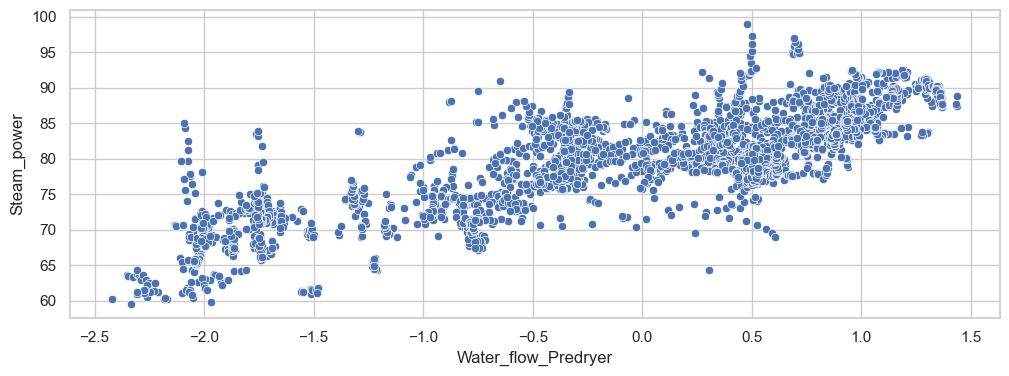

In [11]:
sns.scatterplot(ts_transformed.reset_index(), x="Water_flow_Predryer", y='Steam_power')

In [6]:
# Re-compute split on design matrix
n_samples = len(ts_transformed)
split = int(n_samples * (1.0 - TEST_SIZE))

feature_cols = [c for c in ts_transformed.columns if c != Y_COLUMN]
Xtr = ts_transformed[feature_cols].iloc[:split].copy()
Xte = ts_transformed[feature_cols].iloc[split:].copy()
ytr = ts_transformed[Y_COLUMN].iloc[:split].copy()
yte = ts_transformed[Y_COLUMN].iloc[split:].copy()

print(f'Train: {Xtr.shape}, Test: {Xte.shape}')
print(f'Split at index {split}: train up to {ts_transformed.index[split-1]}, '
      f'test from {ts_transformed.index[split]}')


Train: (2571, 65), Test: (643, 65)
Split at index 2571: train up to 2026-05-29 02:51:30, test from 2026-05-29 03:47:30


In [7]:
# =============================================================================
# delta_y = f(delta_X) - lag sweep (TRAIN ONLY)
# =============================================================================
# The lag is a hyperparameter. Choosing it on the test set would inflate the
# reported performance. So we sweep lags using TimeSeriesSplit WITHIN THE
# TRAIN PORTION ONLY. The test set is touched once, in the next cell, at the
# chosen lag.

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- helpers ----------------------------------------------------------------
def to_hours(index):
    t = pd.DatetimeIndex(index).asi8.astype(np.float64)
    return (t - t[0]) / 3.6e12

def lag_pairs(t_hours, lag_hours, tolerance=0.35):
    '''Find (later, earlier) index pairs separated by ~lag_hours.'''
    target = t_hours - lag_hours
    j = np.searchsorted(t_hours, target)
    j = np.clip(j, 0, len(t_hours) - 1)
    j_alt = np.clip(j - 1, 0, len(t_hours) - 1)
    better = np.abs(t_hours[j_alt] - target) < np.abs(t_hours[j] - target)
    j = np.where(better, j_alt, j)
    realised = t_hours - t_hours[j]
    ok = (j < np.arange(len(t_hours))) & (np.abs(realised - lag_hours) <= tolerance * lag_hours)
    later = np.flatnonzero(ok)
    return later, j[later]

# --- use ONLY the train portion for the sweep -------------------------------
feature_cols = [c for c in ts_transformed.columns if c != Y_COLUMN]
X_all = ts_transformed[feature_cols].values.astype(float)
y_all = ts_transformed[Y_COLUMN].values.astype(float)
t_hours = to_hours(ts_transformed.index)
n = len(ts_transformed)

# Train portion only
X_train = X_all[:split]
y_train = y_all[:split]
t_hours_train = t_hours[:split]

lag_days_grid = [0.25, 0.5, 1, 2, 4, 7, 14]
results = []

for lag_d in lag_days_grid:
    lag_h = lag_d * 24.0
    later, earlier = lag_pairs(t_hours_train, lag_h)
    if len(later) < 200:
        print(f'lag {lag_d:6.2f}d  -- too few pairs ({len(later)}), skipping')
        continue
    dX = X_train[later] - X_train[earlier]
    dy = y_train[later] - y_train[earlier]

    # TimeSeriesSplit CV within the differenced train data
    model = GridSearchCV(
        Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())]),
        param_grid={'ridge__alpha': np.logspace(0, 3, 20).tolist()},
        cv=TimeSeriesSplit(n_splits=5),
        scoring='neg_root_mean_squared_error',
        refit=True,
    )
    model.fit(dX, dy)

    # The score we use to pick the lag is the CV score on the training
    # differenced data (TimeSeriesSplit inside train).
    cv_rmse = -model.best_score_
    cv_r2 = 1 - (cv_rmse**2) / np.var(dy)  # approximate R2 from CV RMSE
    best_alpha = model.best_params_['ridge__alpha']

    results.append({'lag_days': lag_d,
                    'cv_rmse': cv_rmse,
                    'cv_r2_approx': cv_r2,
                    'best_alpha': best_alpha,
                    'n_contrasts': len(later)})
    print(f'lag {lag_d:6.2f}d  '
          f'CV RMSE={cv_rmse:8.3f}  approx R2={cv_r2:+.4f}  '
          f'alpha={best_alpha:.2f}  contrasts={len(later)}')

results_df = pd.DataFrame(results)
best_idx = results_df['cv_rmse'].idxmin()  # best = lowest RMSE
best_lag_d = results_df.loc[best_idx, 'lag_days']
print(f'\nBest lag (by CV RMSE on train): {best_lag_d:.2f} days')


lag   0.25d  CV RMSE=   1.714  approx R2=+0.7322  alpha=1000.00  contrasts=2438
lag   0.50d  CV RMSE=   2.190  approx R2=+0.7805  alpha=1000.00  contrasts=2428
lag   1.00d  CV RMSE=   2.750  approx R2=+0.8293  alpha=1000.00  contrasts=2427
lag   2.00d  CV RMSE=   3.098  approx R2=+0.8799  alpha=695.19  contrasts=2440
lag   4.00d  CV RMSE=   3.441  approx R2=+0.8841  alpha=1000.00  contrasts=2495
lag   7.00d  CV RMSE=   3.345  approx R2=+0.7173  alpha=1000.00  contrasts=2438
lag  14.00d  CV RMSE=   3.503  approx R2=+0.7615  alpha=1000.00  contrasts=2379

Best lag (by CV RMSE on train): 0.25 days


Lag = 0.25 days (chosen on train CV, evaluated on test)
  best alpha: 1000.00
  R2 on differenced target (dy):       +0.8025

  --- vs EWM(y) target ---
  persistence y(t-k):                  R2=+0.6789  MAE=1.81
  y(t-k) + predicted delta:            R2=+0.9367  MAE=0.87
  gain over persistence:               +0.2578 R2

  --- vs RAW y target (no EWM) ---
  persistence y_raw(t-k):              R2=+0.6033  MAE=2.40
  EWM(y)(t-k) + predicted delta:       R2=+0.8948  MAE=1.26
  gain over persistence:               +0.2916 R2


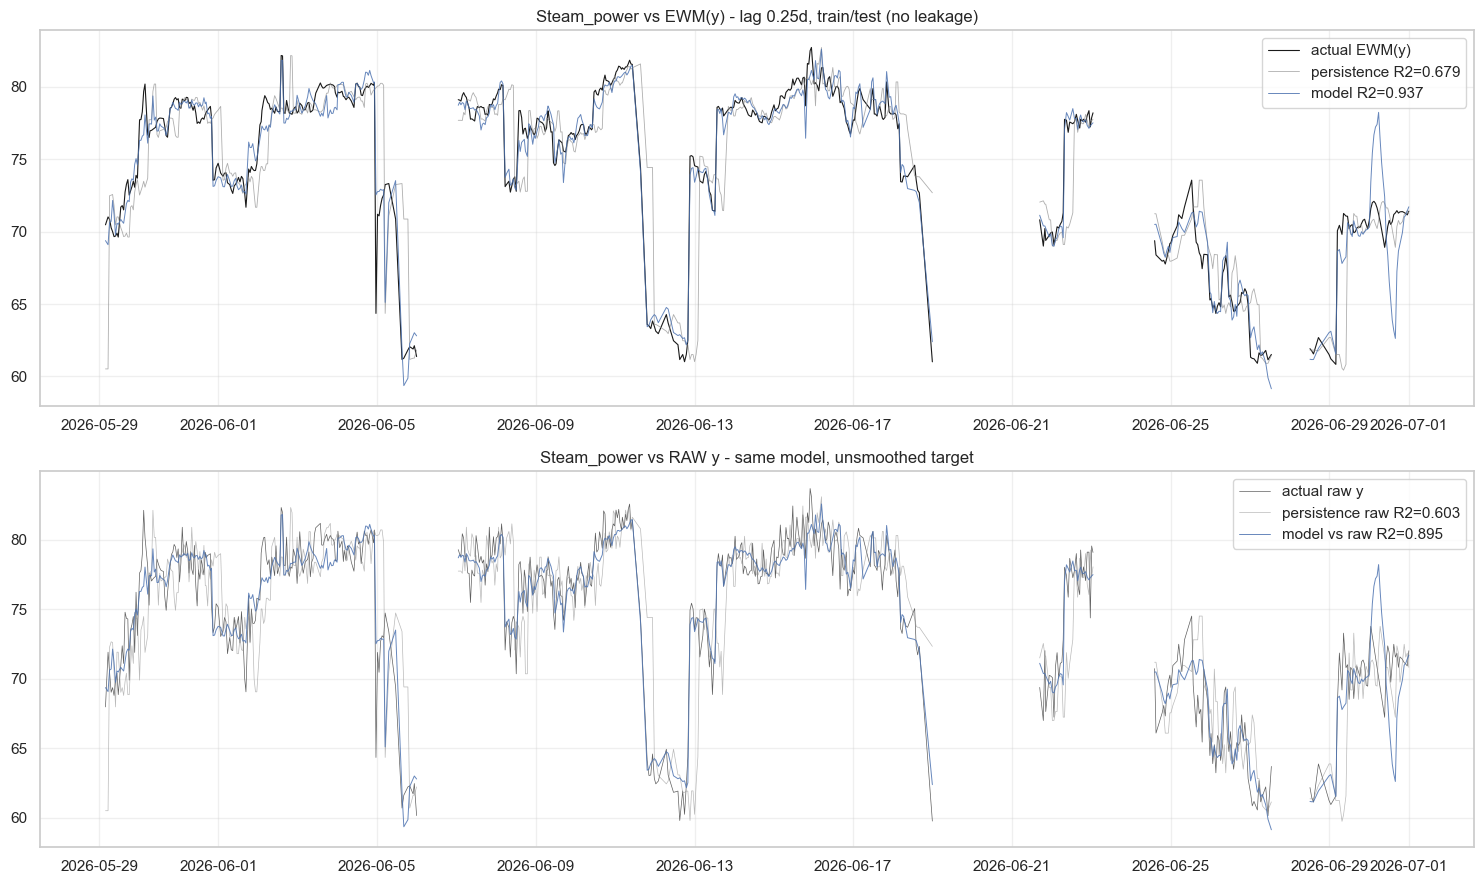

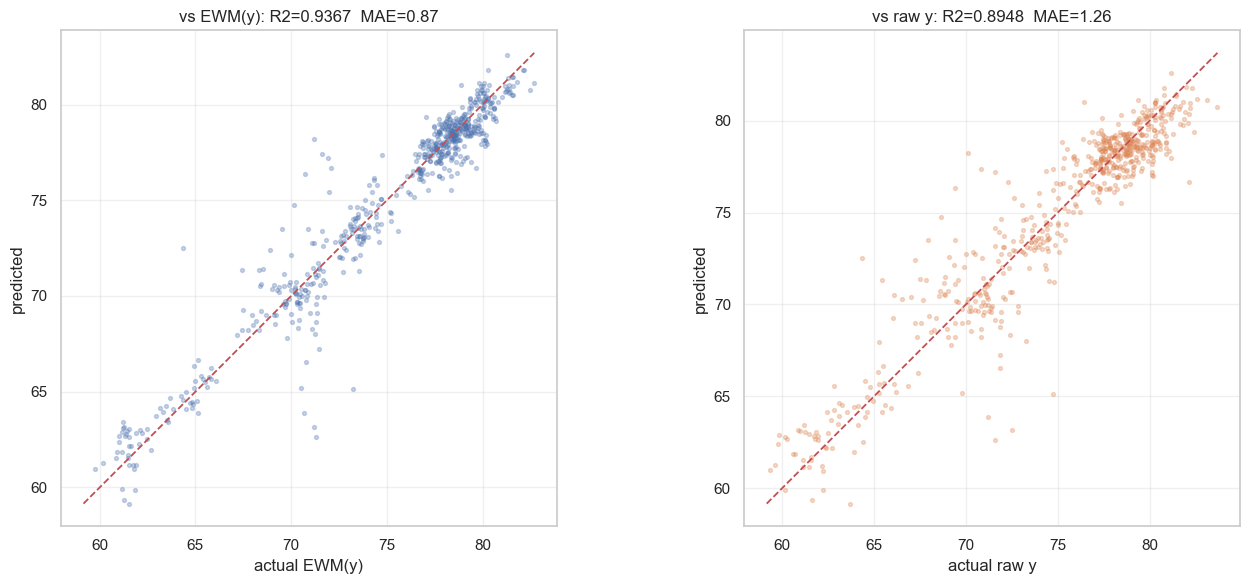

In [8]:
# =============================================================================
# Evaluate at the best lag on the UNTOUCHED TEST SET
# =============================================================================
# The lag was chosen on train-only CV. Now we fit once on ALL train contrasts
# at that lag, and report on the test contrasts.
# Compare predictions against BOTH EWM(y) and raw y.

lag_h = best_lag_d * 24.0

# Pairs over the full series (test contrasts may have their earlier member in train)
later, earlier = lag_pairs(t_hours, lag_h)
dX = X_all[later] - X_all[earlier]
dy = y_all[later] - y_all[earlier]

# Train: both members in train. Test: later member in test.
tr_sel = later < split
te_sel = later >= split

# Fit on train contrasts
model = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())]),
    param_grid={'ridge__alpha': np.logspace(0, 3, 20).tolist()},
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_root_mean_squared_error',
    refit=True,
)
model.fit(dX[tr_sel], dy[tr_sel])
pred_test = model.predict(dX[te_sel])

t_anchor = ts_transformed.index[later[te_sel]]

# --- Evaluation against EWM(y) ---
actual_ewm = y_all[later[te_sel]]
persistence_ewm = y_all[earlier[te_sel]]
model_ewm = persistence_ewm + pred_test

r2_pers_ewm = r2_score(actual_ewm, persistence_ewm)
r2_model_ewm = r2_score(actual_ewm, model_ewm)
r2_dy = r2_score(dy[te_sel], pred_test)

# --- Evaluation against RAW y (no EWM) ---
actual_raw_test = y_raw[later[te_sel]]
persistence_raw = y_raw[earlier[te_sel]]
# Model prediction anchored on EWM(y)(t-k) + predicted delta
# This is what the model actually produces.
# Compare against raw y to see how it performs on the unsmoothed target.
model_vs_raw = persistence_ewm + pred_test  # model output is the same

r2_pers_raw = r2_score(actual_raw_test, persistence_raw)
r2_model_raw = r2_score(actual_raw_test, model_vs_raw)

print(f'Lag = {best_lag_d:.2f} days (chosen on train CV, evaluated on test)')
print(f'  best alpha: {model.best_params_["ridge__alpha"]:.2f}')
print(f'  R2 on differenced target (dy):       {r2_dy:+.4f}')
print()
print(f'  --- vs EWM(y) target ---')
print(f'  persistence y(t-k):                  R2={r2_pers_ewm:+.4f}  MAE={mean_absolute_error(actual_ewm, persistence_ewm):.2f}')
print(f'  y(t-k) + predicted delta:            R2={r2_model_ewm:+.4f}  MAE={mean_absolute_error(actual_ewm, model_ewm):.2f}')
print(f'  gain over persistence:               {r2_model_ewm - r2_pers_ewm:+.4f} R2')
print()
print(f'  --- vs RAW y target (no EWM) ---')
print(f'  persistence y_raw(t-k):              R2={r2_pers_raw:+.4f}  MAE={mean_absolute_error(actual_raw_test, persistence_raw):.2f}')
print(f'  EWM(y)(t-k) + predicted delta:       R2={r2_model_raw:+.4f}  MAE={mean_absolute_error(actual_raw_test, model_vs_raw):.2f}')
print(f'  gain over persistence:               {r2_model_raw - r2_pers_raw:+.4f} R2')

# --- timeseries plot -------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Break gaps so lines don't span shutdowns
dt_hours = np.diff(pd.DatetimeIndex(t_anchor).asi8.astype(float) / 3.6e12)
gap_idx = np.flatnonzero(dt_hours > 12)

def plot_with_gaps(ax, t, series_dict, gap_idx):
    for label, (vals, kwargs) in series_dict.items():
        v = vals.copy().astype(float)
        v[gap_idx] = np.nan  # break the line
        ax.plot(t, v, label=label, **kwargs)

# Top panel: vs EWM target
plot_with_gaps(axes[0], t_anchor, {
    'actual EWM(y)': (actual_ewm, {'lw': 0.8, 'color': 'k'}),
    f'persistence R2={r2_pers_ewm:.3f}': (persistence_ewm, {'lw': 0.6, 'color': 'C7', 'alpha': 0.7}),
    f'model R2={r2_model_ewm:.3f}': (model_ewm, {'lw': 0.7, 'color': 'C0', 'alpha': 0.85}),
}, gap_idx)
axes[0].legend()
axes[0].set_title(f'{Y_COLUMN} vs EWM(y) - lag {best_lag_d:.2f}d, train/test (no leakage)')
axes[0].grid(alpha=0.3)

# Bottom panel: vs raw y
plot_with_gaps(axes[1], t_anchor, {
    'actual raw y': (actual_raw_test, {'lw': 0.5, 'color': 'k', 'alpha': 0.7}),
    f'persistence raw R2={r2_pers_raw:.3f}': (persistence_raw, {'lw': 0.5, 'color': 'C7', 'alpha': 0.6}),
    f'model vs raw R2={r2_model_raw:.3f}': (model_vs_raw, {'lw': 0.7, 'color': 'C0', 'alpha': 0.85}),
}, gap_idx)
axes[1].legend()
axes[1].set_title(f'{Y_COLUMN} vs RAW y - same model, unsmoothed target')
axes[1].grid(alpha=0.3)

plt.tight_layout()

# --- Scatter plots: pred vs actual ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: vs EWM(y)
axes[0].scatter(actual_ewm, model_ewm, s=8, alpha=0.3)
lim = [min(actual_ewm.min(), model_ewm.min()), max(actual_ewm.max(), model_ewm.max())]
axes[0].plot(lim, lim, 'r--', lw=1.3)
axes[0].set_xlabel('actual EWM(y)'); axes[0].set_ylabel('predicted')
axes[0].set_title(f'vs EWM(y): R2={r2_model_ewm:.4f}  MAE={mean_absolute_error(actual_ewm, model_ewm):.2f}')
axes[0].set_aspect('equal', adjustable='box'); axes[0].grid(alpha=0.3)

# Right: vs raw y
axes[1].scatter(actual_raw_test, model_vs_raw, s=8, alpha=0.3, color='C1')
lim = [min(actual_raw_test.min(), model_vs_raw.min()), max(actual_raw_test.max(), model_vs_raw.max())]
axes[1].plot(lim, lim, 'r--', lw=1.3)
axes[1].set_xlabel('actual raw y'); axes[1].set_ylabel('predicted')
axes[1].set_title(f'vs raw y: R2={r2_model_raw:.4f}  MAE={mean_absolute_error(actual_raw_test, model_vs_raw):.2f}')
axes[1].set_aspect('equal', adjustable='box'); axes[1].grid(alpha=0.3)

plt.tight_layout()


c:\workspace\costimiser\training\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\workspace\costimiser\training\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
c:\workspace\costimiser\training\.venv\Lib\site-packages\pytorch_lightning\trainer\setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_epochs=256` reached.
c:\workspace\costimiser\training\.ven

=== RealMLP at lag 0.25d ===
  R2 on differenced target (dy):       +0.0007  (Ridge: +0.2075)

  --- vs EWM(y) target ---
  persistence:                         R2=+0.5454
  RealMLP:                             R2=+0.5464  (Ridge: +0.6403)
  gain over persistence:               +0.0010  (Ridge: +0.0949)

  --- vs RAW y target ---
  persistence:                         R2=+0.1087
  RealMLP:                             R2=+0.3844  (Ridge: +0.4486)
  gain over persistence:               +0.2757  (Ridge: +0.3398)


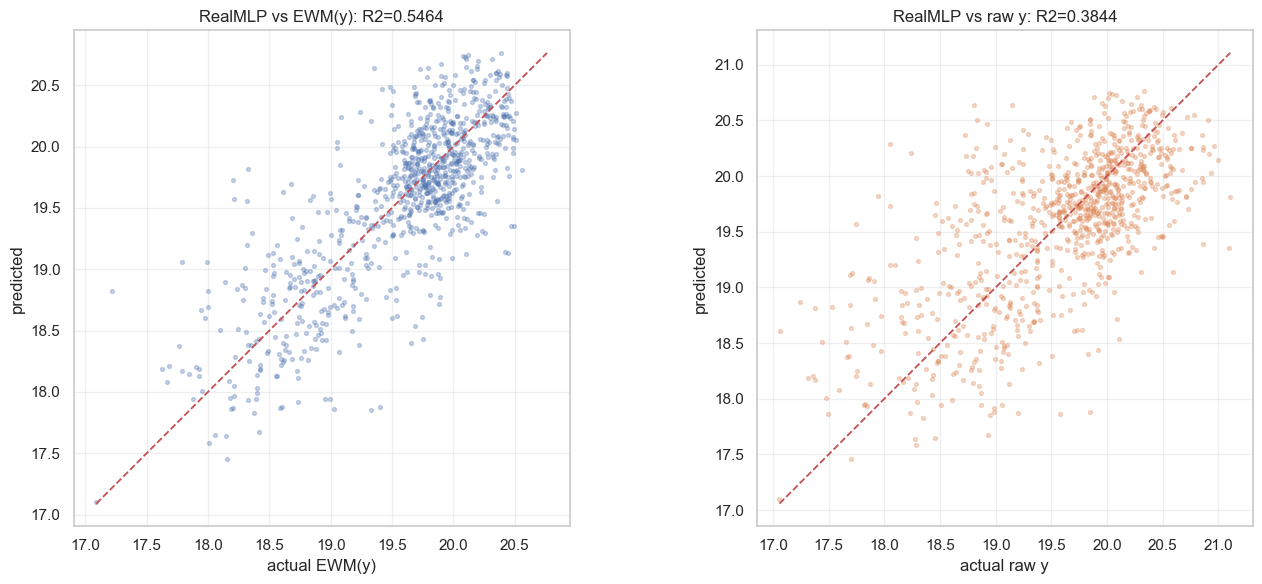

In [13]:
# =============================================================================
# RealMLP on delta_y = f(delta_X) at the best lag
# =============================================================================
# Same protocol as Ridge: fit on train contrasts, evaluate on test.
# RealMLP was previously impossible because the latent level competed with
# the flexible model. With differencing the nuisance is gone before fitting,
# so a flexible learner can be used without risk of absorption.

from pytabkit import RealMLP_TD_S_Regressor

lag_h = best_lag_d * 24.0
later, earlier = lag_pairs(t_hours, lag_h)
dX = X_all[later] - X_all[earlier]
dy = y_all[later] - y_all[earlier]

tr_sel = later < split
te_sel = later >= split

# Standardise (RealMLP benefits from normalised inputs)
scaler_mlp = StandardScaler()
dX_tr_scaled = scaler_mlp.fit_transform(dX[tr_sel])
dX_te_scaled = scaler_mlp.transform(dX[te_sel])

mlp = RealMLP_TD_S_Regressor(device='cpu', random_state=42, verbosity=0)
mlp.fit(dX_tr_scaled, dy[tr_sel])
pred_test_mlp = mlp.predict(dX_te_scaled).ravel()

# --- Metrics ---
actual_ewm_mlp = y_all[later[te_sel]]
persistence_ewm_mlp = y_all[earlier[te_sel]]
model_ewm_mlp = persistence_ewm_mlp + pred_test_mlp

actual_raw_mlp = y_raw[later[te_sel]]
persistence_raw_mlp = y_raw[earlier[te_sel]]
model_raw_mlp = persistence_ewm_mlp + pred_test_mlp

r2_dy_mlp = r2_score(dy[te_sel], pred_test_mlp)
r2_ewm_mlp = r2_score(actual_ewm_mlp, model_ewm_mlp)
r2_raw_mlp = r2_score(actual_raw_mlp, model_raw_mlp)

print(f'=== RealMLP at lag {best_lag_d:.2f}d ===')
print(f'  R2 on differenced target (dy):       {r2_dy_mlp:+.4f}  (Ridge: {r2_dy:+.4f})')
print()
print(f'  --- vs EWM(y) target ---')
print(f'  persistence:                         R2={r2_pers_ewm:+.4f}')
print(f'  RealMLP:                             R2={r2_ewm_mlp:+.4f}  (Ridge: {r2_model_ewm:+.4f})')
print(f'  gain over persistence:               {r2_ewm_mlp - r2_pers_ewm:+.4f}  (Ridge: {r2_model_ewm - r2_pers_ewm:+.4f})')
print()
print(f'  --- vs RAW y target ---')
print(f'  persistence:                         R2={r2_pers_raw:+.4f}')
print(f'  RealMLP:                             R2={r2_raw_mlp:+.4f}  (Ridge: {r2_model_raw:+.4f})')
print(f'  gain over persistence:               {r2_raw_mlp - r2_pers_raw:+.4f}  (Ridge: {r2_model_raw - r2_pers_raw:+.4f})')

# --- Scatter plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(actual_ewm_mlp, model_ewm_mlp, s=8, alpha=0.3)
lim = [min(actual_ewm_mlp.min(), model_ewm_mlp.min()), max(actual_ewm_mlp.max(), model_ewm_mlp.max())]
axes[0].plot(lim, lim, 'r--', lw=1.3)
axes[0].set_xlabel('actual EWM(y)'); axes[0].set_ylabel('predicted')
axes[0].set_title(f'RealMLP vs EWM(y): R2={r2_ewm_mlp:.4f}')
axes[0].set_aspect('equal', adjustable='box'); axes[0].grid(alpha=0.3)

axes[1].scatter(actual_raw_mlp, model_raw_mlp, s=8, alpha=0.3, color='C1')
lim = [min(actual_raw_mlp.min(), model_raw_mlp.min()), max(actual_raw_mlp.max(), model_raw_mlp.max())]
axes[1].plot(lim, lim, 'r--', lw=1.3)
axes[1].set_xlabel('actual raw y'); axes[1].set_ylabel('predicted')
axes[1].set_title(f'RealMLP vs raw y: R2={r2_raw_mlp:.4f}')
axes[1].set_aspect('equal', adjustable='box'); axes[1].grid(alpha=0.3)

plt.tight_layout()


c:\workspace\costimiser\training\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\workspace\costimiser\training\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
c:\workspace\costimiser\training\.venv\Lib\site-packages\pytorch_lightning\trainer\setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Train contrasts: 3678 -> fit: 2943, val: 735
Test contrasts: 914
Columns classified as continuous: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Columns classified as categorical: []
Epoch 1/256: val rmse = 0.686903
Epoch 2/256: val rmse = 0.668805
Epoch 3/256: val rmse = 0.631205
Epoch 4/256: val rmse = 0.584253
Epoch 5/256: val rmse = 0.538402
Epoch 6/256: val rmse = 0.497919
Epoch 7/256: val rmse = 0.465048
Epoch 8/256: val rmse = 0.438040
Epoch 9/256: val rmse = 0.418121
Epoch 10/256: val rmse = 0.404090
Epoch 11/256: val rmse = 0.395863
Epoch 12/256: val rmse = 0.389694
Epoch 13/256: val rmse = 0.385612
Epoch 14/256: val rmse = 0.383319
Epoch 15/256: val rmse = 0.382199
Epoch 16/256: val rmse = 0.381815
Epoch 17/256: val rmse = 0.381750
Epoch 18/256: val rmse = 0.381711
Epoch 19/256: val rmse = 0.381406
Epoch 20/256: val rmse = 0.380616
Epoch 21/256: val rmse = 0.379042
Epoch 22/256: val rmse = 0.376724
Epoch 23/256: val rmse = 0.374203
Epoch 24/25

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
c:\workspace\costimiser\training\.venv\Lib\site-packages\pytorch_lightning\trainer\setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Refit Epoch 0/96
Refit Epoch 1/96
Refit Epoch 2/96
Refit Epoch 3/96
Refit Epoch 4/96
Refit Epoch 5/96
Refit Epoch 6/96
Refit Epoch 7/96
Refit Epoch 8/96
Refit Epoch 9/96
Refit Epoch 10/96
Refit Epoch 11/96
Refit Epoch 12/96
Refit Epoch 13/96
Refit Epoch 14/96
Refit Epoch 15/96
Refit Epoch 16/96
Refit Epoch 17/96
Refit Epoch 18/96
Refit Epoch 19/96
Refit Epoch 20/96
Refit Epoch 21/96
Refit Epoch 22/96
Refit Epoch 23/96
Refit Epoch 24/96
Refit Epoch 25/96
Refit Epoch 26/96
Refit Epoch 27/96
Refit Epoch 28/96
Refit Epoch 29/96
Refit Epoch 30/96
Refit Epoch 31/96
Refit Epoch 32/96
Refit Epoch 33/96
Refit Epoch 34/96
Refit Epoch 35/96
Refit Epoch 36/96
Refit Epoch 37/96
Refit Epoch 38/96
Refit Epoch 39/96
Refit Epoch 40/96
Refit Epoch 41/96
Refit Epoch 42/96
Refit Epoch 43/96
Refit Epoch 44/96
Refit Epoch 45/96
Refit Epoch 46/96
Refit Epoch 47/96
Refit Epoch 48/96
Refit Epoch 49/96
Refit Epoch 50/96
Refit Epoch 51/96
Refit Epoch 52/96
Refit Epoch 53/96
Refit Epoch 54/96
Refit Epoch 55/96
Re

c:\workspace\costimiser\training\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
c:\workspace\costimiser\training\.venv\Lib\site-packages\pytorch_lightning\trainer\setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



=== RealMLP (early stopping) at lag 0.25d ===
  R2 on dy:              +0.1773  (no ES: +0.0007, Ridge: +0.2075)
  vs EWM(y):             R2=+0.6266  (no ES: +0.5464, Ridge: +0.6403)
  vs raw y:              R2=+0.4410  (no ES: +0.3844, Ridge: +0.4486)
  gain over persistence (EWM): +0.0812
  gain over persistence (raw): +0.3322


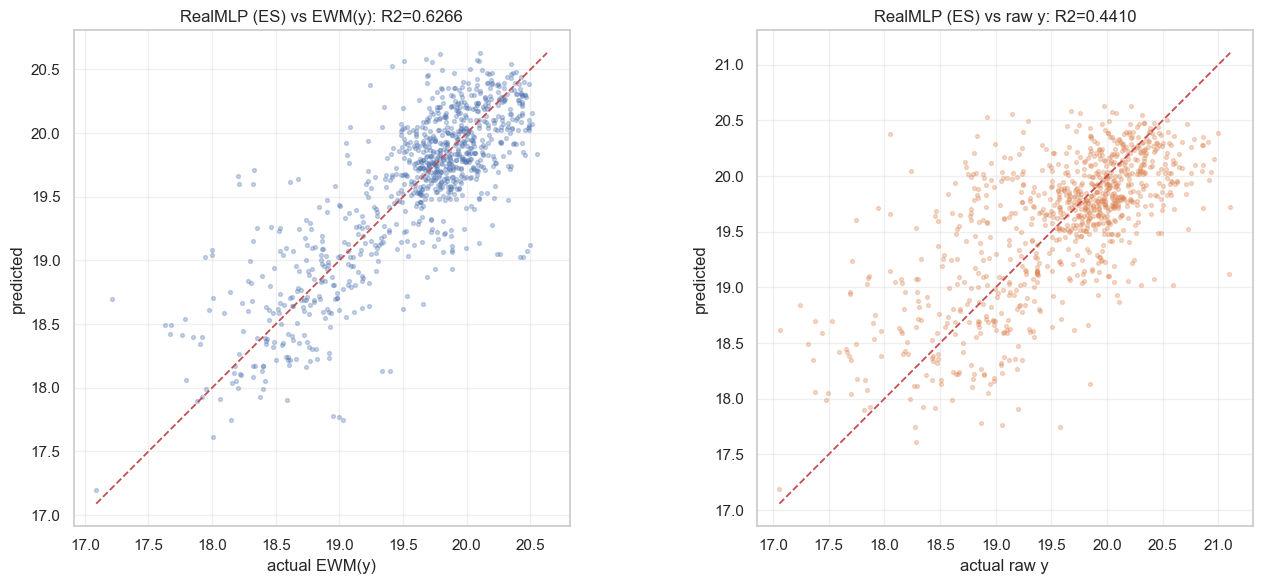

In [14]:
# =============================================================================
# RealMLP with early stopping (train/val split from training data)
# =============================================================================
# Use the last 20% of the TRAIN contrasts as a validation set for early
# stopping. This is chronological: val is the most recent part of training,
# which is the hardest (closest to the regime the test set lives in).

from pytabkit import RealMLP_TD_Regressor

lag_h = best_lag_d * 24.0
later, earlier = lag_pairs(t_hours, lag_h)
dX = X_all[later] - X_all[earlier]
dy = y_all[later] - y_all[earlier]

tr_sel = later < split
te_sel = later >= split

# Split train contrasts into fit / val (chronological, last 20% as val)
n_train_contrasts = int(tr_sel.sum())
val_frac = 0.20
n_val = int(n_train_contrasts * val_frac)
n_fit = n_train_contrasts - n_val

tr_indices = np.flatnonzero(tr_sel)
fit_idx = tr_indices[:n_fit]
val_idx = tr_indices[n_fit:]

print(f'Train contrasts: {n_train_contrasts} -> fit: {n_fit}, val: {n_val}')
print(f'Test contrasts: {int(te_sel.sum())}')

# Standardise
scaler_mlp2 = StandardScaler()
dX_fit = scaler_mlp2.fit_transform(dX[fit_idx])
dX_val = scaler_mlp2.transform(dX[val_idx])
dX_te = scaler_mlp2.transform(dX[te_sel])

dy_fit = dy[fit_idx]
dy_val = dy[val_idx]

# RealMLP with validation data for early stopping
mlp2 = RealMLP_TD_Regressor(
    device='cpu',
    random_state=42,
    verbosity=2,
    n_cv=1,  # no internal CV, use our explicit val set
    val_fraction=0.0,  # we provide val externally,
    n_epochs=256*1, 
    hidden_sizes=[64] * 2, 
    use_early_stopping=True,
    n_refit=5, 
    lr=0.0001,
    batch_size=32
)
mlp2.fit(dX_fit, dy_fit,
         X_val=dX_val, y_val=dy_val)
pred_test_mlp2 = mlp2.predict(dX_te).ravel()

# --- Metrics ---
actual_ewm_mlp2 = y_all[later[te_sel]]
persistence_ewm_mlp2 = y_all[earlier[te_sel]]
model_ewm_mlp2 = persistence_ewm_mlp2 + pred_test_mlp2

actual_raw_mlp2 = y_raw[later[te_sel]]
model_raw_mlp2 = persistence_ewm_mlp2 + pred_test_mlp2

r2_dy_mlp2 = r2_score(dy[te_sel], pred_test_mlp2)
r2_ewm_mlp2 = r2_score(actual_ewm_mlp2, model_ewm_mlp2)
r2_raw_mlp2 = r2_score(actual_raw_mlp2, model_raw_mlp2)

print(f'\n=== RealMLP (early stopping) at lag {best_lag_d:.2f}d ===')
print(f'  R2 on dy:              {r2_dy_mlp2:+.4f}  (no ES: {r2_dy_mlp:+.4f}, Ridge: {r2_dy:+.4f})')
print(f'  vs EWM(y):             R2={r2_ewm_mlp2:+.4f}  (no ES: {r2_ewm_mlp:+.4f}, Ridge: {r2_model_ewm:+.4f})')
print(f'  vs raw y:              R2={r2_raw_mlp2:+.4f}  (no ES: {r2_raw_mlp:+.4f}, Ridge: {r2_model_raw:+.4f})')
print(f'  gain over persistence (EWM): {r2_ewm_mlp2 - r2_pers_ewm:+.4f}')
print(f'  gain over persistence (raw): {r2_raw_mlp2 - r2_pers_raw:+.4f}')

# --- Scatter plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(actual_ewm_mlp2, model_ewm_mlp2, s=8, alpha=0.3)
lim = [min(actual_ewm_mlp2.min(), model_ewm_mlp2.min()), max(actual_ewm_mlp2.max(), model_ewm_mlp2.max())]
axes[0].plot(lim, lim, 'r--', lw=1.3)
axes[0].set_xlabel('actual EWM(y)'); axes[0].set_ylabel('predicted')
axes[0].set_title(f'RealMLP (ES) vs EWM(y): R2={r2_ewm_mlp2:.4f}')
axes[0].set_aspect('equal', adjustable='box'); axes[0].grid(alpha=0.3)

axes[1].scatter(actual_raw_mlp2, model_raw_mlp2, s=8, alpha=0.3, color='C1')
lim = [min(actual_raw_mlp2.min(), model_raw_mlp2.min()), max(actual_raw_mlp2.max(), model_raw_mlp2.max())]
axes[1].plot(lim, lim, 'r--', lw=1.3)
axes[1].set_xlabel('actual raw y'); axes[1].set_ylabel('predicted')
axes[1].set_title(f'RealMLP (ES) vs raw y: R2={r2_raw_mlp2:.4f}')
axes[1].set_aspect('equal', adjustable='box'); axes[1].grid(alpha=0.3)

plt.tight_layout()


In [19]:
# =============================================================================
# Inference abstraction: model.predict(modified_row)
# =============================================================================
# For optimisation we don't predict the future - we ask "what would y be if I
# changed these setpoints at this moment?". The anchor is the SAME row before
# modification, so the lag is irrelevant at inference time.
#
# The model wraps:
#   - pre_estimator: transforms raw columns -> EWM-filtered features
#   - ridge: fitted on delta_y = f(delta_X)
#   - reference table: all of turnup_data after EWM transform (X and y)
#
# Usage:
#   row = turnup_ts.iloc[100].copy()   # pick a real operating point
#   row['Jet/wire_ratio'] += 0.05      # tweak a setpoint
#   predicted_y = diff_model.predict(row)

class DifferencingModel:
    def __init__(self, pre_estimator, estimator, reference_X, reference_y,
                 feat_list, feature_cols, scaler=None):
        """
        Parameters
        ----------
        pre_estimator : fitted preprocessing pipeline
        estimator     : fitted model (Ridge, SplineRidge, or RealMLP)
        reference_X   : DataFrame of EWM-transformed features (all rows)
        reference_y   : array/Series of EWM(y) for all rows
        feat_list     : raw input columns needed by pre_estimator
        feature_cols  : columns the estimator expects after transform
        scaler        : optional StandardScaler (for RealMLP)
        """
        self.pre_estimator = pre_estimator
        self.estimator = estimator
        self.reference_X = reference_X
        self.reference_y = np.asarray(reference_y, dtype=float)
        self.feat_list = feat_list
        self.feature_cols = feature_cols
        self.scaler = scaler
        # Build a timestamp -> integer index map for fast lookup
        self._idx_map = {t: i for i, t in enumerate(reference_X.index)}

    def predict(self, row):
        """
        Predict y for a modified row.

        row : Series or 1-row DataFrame from turnup_ts (raw columns),
              with some setpoints modified. Must have the same index
              (timestamp) as a row in the reference table.

        Returns: float predicted y
        """
        if isinstance(row, pd.DataFrame):
            if len(row) != 1:
                raise ValueError('pass a single row (Series or 1-row DataFrame)')
            row = row.iloc[0]

        ts = row.name
        if ts not in self._idx_map:
            raise KeyError(f'timestamp {ts} not in reference table')
        idx = self._idx_map[ts]

        # Transform the modified row through preprocessing
        row_df = pd.DataFrame([row[self.feat_list]], columns=self.feat_list,
                              index=pd.DatetimeIndex([ts]))
        X_modified = self.pre_estimator.transform(row_df)

        # Reference (original) features at the same timestamp
        X_ref = self.reference_X.iloc[idx][self.feature_cols].values
        y_ref = self.reference_y[idx]

        # Delta
        dX = X_modified[self.feature_cols].values.ravel() - X_ref
        dX = dX.reshape(1, -1)

        # Apply scaler if present (RealMLP)
        if self.scaler is not None:
            dX = self.scaler.transform(dX)

        # Predict delta
        dy_pred = self.estimator.predict(dX)
        if hasattr(dy_pred, 'ravel'):
            dy_pred = dy_pred.ravel()[0]

        return float(y_ref + dy_pred)

    def predict_batch(self, rows_df):
        """Predict for multiple modified rows (same timestamps must exist in reference)."""
        return np.array([self.predict(rows_df.iloc[i]) for i in range(len(rows_df))])

    def sensitivity(self, row, feature, delta):
        """
        How much does y change if `feature` changes by `delta` from this row?
        Returns (y_original, y_modified, change).
        """
        y_orig = self.predict(row)
        row_mod = row.copy()
        row_mod[feature] = row_mod[feature] + delta
        y_mod = self.predict(row_mod)
        return y_orig, y_mod, y_mod - y_orig


# --- Build the model from what we already have ---
# reference_X = ts_transformed with only feature columns
# reference_y = EWM(y) = ts_transformed[Y_COLUMN]
# The Ridge model was fitted in cell [7] (variable: `model`)

diff_model = DifferencingModel(
    pre_estimator=pre_estimator,
    estimator=model.best_estimator_,  # the refitted Pipeline from GridSearchCV
    reference_X=ts_transformed[feature_cols].copy(),
    reference_y=ts_transformed[Y_COLUMN].values.copy(),
    feat_list=feat_list,
    feature_cols=feature_cols,
    scaler=None,  # Ridge pipeline has its own scaler
)

# --- Test it ---
# Pick a row from the test set, predict without changes (should give ~ 0 delta)
test_row = turnup_ts.iloc[split + 10].copy()
y_baseline = diff_model.predict(test_row)
print(f'Baseline prediction (no change): {y_baseline:.2f}')
print(f'Actual EWM(y) at that point:     {diff_model.reference_y[split + 10]:.2f}')
print(f'Difference (should be ~0):       {y_baseline - diff_model.reference_y[split + 10]:.4f}')

# Now tweak a setpoint and see the effect
print(f'\n--- Sensitivity examples ---')
for feat, delta in [('Jet/wire_ratio', 0.01), ('White_water_temperature', 1.0),
                     ('ambient_temp_C', 5.0)]:
    if feat in test_row.index:
        y0, y1, dy = diff_model.sensitivity(test_row, feat, delta)
        print(f'  {feat:40s} +{delta:6.3f} -> dy = {dy:+.2f}')


Baseline prediction (no change): 72.50
Actual EWM(y) at that point:     71.79
Difference (should be ~0):       0.7109

--- Sensitivity examples ---
  Jet/wire_ratio                           + 0.010 -> dy = -0.00
  White_water_temperature                  + 1.000 -> dy = +0.08
  ambient_temp_C                           + 5.000 -> dy = -0.22
